# 09 - Advanced ideas and next steps

The course system is deliberately simple. This closing notebook develops two
techniques that directly strengthen it - **sequential change detection** and
**conformal prediction** - each with the theory and a runnable demo, and then lays
out a research roadmap for the pieces we only sketched.

## Part A - Sequential change detection (CUSUM)

The capstone (notebook 08) found that a single-sample gate on the NIS is
*intermittent*: under a bias the filter partly tracks, the NIS spikes cross the
threshold only ~30% of the time, so as a standalone trigger the gate is weak. The
fix is to accumulate evidence over time.

**From the SPRT to CUSUM.** Detecting a change from an in-control density $p_0$ to an
out-of-control $p_1$ as quickly as possible, subject to a false-alarm budget, is a
sequential-testing problem. Wald's sequential probability ratio test accumulates the
**log-likelihood ratio** $s_k=\log\frac{p_1(z_k)}{p_0(z_k)}$; Page's **CUSUM** [1]
applies it with a reset at zero,

$$ g_k=\max\!\big(0,\ g_{k-1}+s_k\big),\qquad \text{alarm when } g_k>h. $$

For detecting a **mean increase** this reduces to $g_k=\max(0,\,g_{k-1}+z_k-k_{ref})$
with reference $k_{ref}\approx(\mu_0+\mu_1)/2$: below the change the increments are
negative and $g_k$ is pinned near $0$ (few false alarms); after the change they turn
positive and $g_k$ ramps up (fast detection). CUSUM is **asymptotically optimal** -
it minimises the worst-case expected detection delay for a given false-alarm rate
[3,4].

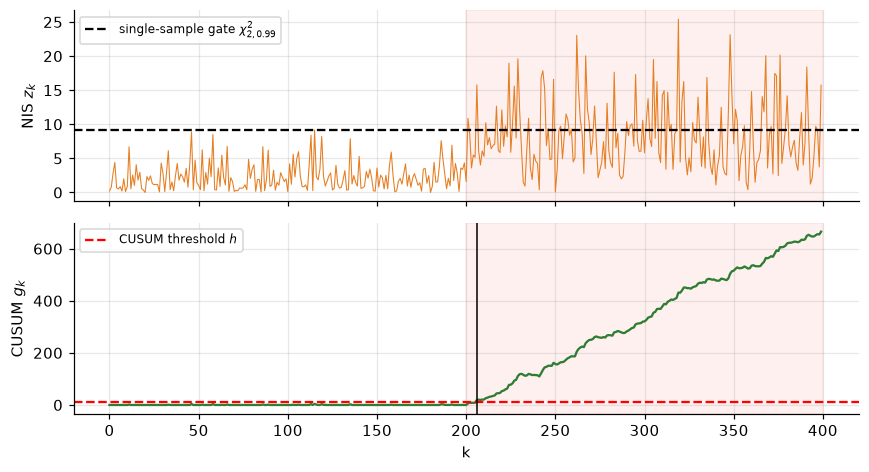

change at k=200 :  CUSUM detects at k=206 (delay 6) ;  first single-sample gate crossing at k=201


In [1]:
import numpy as np, matplotlib.pyplot as plt
rng = np.random.default_rng(0)

# NIS-like stream: in-control ~ chi^2_2 (mean 2), out-of-control ~ noncentral chi^2 (mean ~8)
ic = lambda size: rng.chisquare(2, size)
oc = lambda size: rng.noncentral_chisquare(2, 6.0, size)

zr = np.random.default_rng(3)
N, change = 400, 200
z = np.concatenate([zr.chisquare(2, change), zr.noncentral_chisquare(2, 6.0, N - change)])
kref, h = 5.0, 10.0
g = np.zeros(N)
for t in range(1, N):
    g[t] = max(0.0, g[t-1] + z[t] - kref)
cusum_alarm = int(np.argmax(g > h)) if (g > h).any() else None
gate_alarm  = change + int(np.argmax(z[change:] > 9.21)) if (z[change:] > 9.21).any() else None

fig, ax = plt.subplots(2, 1, figsize=(8, 4.4), sharex=True)
ax[0].plot(z, color="#e67e22", lw=.7); ax[0].axhline(9.21, ls="--", color="k", label="single-sample gate $\\chi^2_{2,0.99}$")
ax[0].axvspan(change, N, color="red", alpha=.06); ax[0].set_ylabel("NIS $z_k$"); ax[0].legend(loc="upper left", fontsize=8)
ax[1].plot(g, color="#2e7d32"); ax[1].axhline(h, ls="--", color="r", label="CUSUM threshold $h$")
if cusum_alarm: ax[1].axvline(cusum_alarm, color="k", lw=1)
ax[1].axvspan(change, N, color="red", alpha=.06); ax[1].set_ylabel("CUSUM $g_k$"); ax[1].set_xlabel("k")
ax[1].legend(loc="upper left", fontsize=8)
for a in ax: a.grid(alpha=.3)
plt.tight_layout(); plt.show()
print("change at k=%d :  CUSUM detects at k=%s (delay %s) ;  first single-sample gate crossing at k=%s"
      % (change, cusum_alarm, cusum_alarm-change if cusum_alarm else None, gate_alarm))

### The operating characteristic: ARL

Detector quality is summarised by the **average run length (ARL)**: $\mathrm{ARL}_0$ is
the mean time *between false alarms* while in control (want it large), and
$\mathrm{ARL}_1$ is the mean *detection delay* once the change occurs (want it small)
[4]. Sweeping the threshold traces a trade-off curve. Below we compare CUSUM against
the memoryless single-sample gate on the same streams: for any given false-alarm
interval, CUSUM detects far sooner - which is exactly the robustness the capstone was
missing.

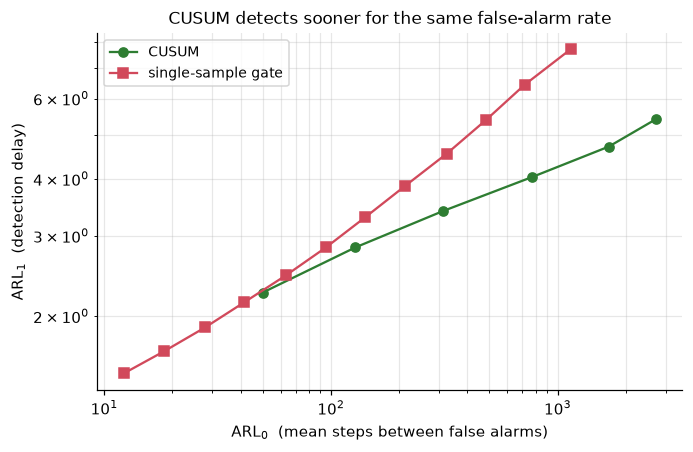

In [2]:
def arl(gen, kref, h, R=4000, maxT=4000):
    g = np.zeros(R); rl = np.full(R, float(maxT)); fired = np.zeros(R, bool)
    for t in range(1, maxT + 1):
        g = np.maximum(0.0, g + gen(R) - kref)
        nf = (~fired) & (g > h); rl[nf] = t; fired |= nf
        if fired.all(): break
    return rl.mean()

hs = np.arange(3, 15, 2)
cusum0 = np.array([arl(ic, kref, hh) for hh in hs])   # in-control -> false-alarm interval
cusum1 = np.array([arl(oc, kref, hh) for hh in hs])   # out-of-control -> detection delay

thr = np.linspace(5, 14, 12)                          # single-sample gate on z
Zic, Zoc = ic(400000), oc(400000)
gate0 = np.array([1/np.mean(Zic > t) for t in thr])
gate1 = np.array([1/np.mean(Zoc > t) for t in thr])

plt.figure(figsize=(6.4, 4.2))
plt.loglog(cusum0, cusum1, '-o', color="#2e7d32", label="CUSUM")
plt.loglog(gate0, gate1, '-s', color="#d1495b", label="single-sample gate")
plt.xlabel("$\\mathrm{ARL}_0$  (mean steps between false alarms)")
plt.ylabel("$\\mathrm{ARL}_1$  (detection delay)")
plt.title("CUSUM detects sooner for the same false-alarm rate")
plt.legend(); plt.grid(alpha=.3, which="both"); plt.tight_layout(); plt.show()

## Part B - Conformal prediction

Ensembles (notebook 04) give a spread but no *guarantee*. **Conformal prediction** [5]
wraps any model to produce prediction sets with a finite-sample, distribution-free
coverage guarantee.

**Split conformal.** Hold out a calibration set of $n$ points, compute nonconformity
scores $R_i=|y_i-\hat f(x_i)|$, and take $q=$ the $\lceil(n+1)(1-\alpha)\rceil$-th
smallest. The interval $\hat f(x)\pm q$ then satisfies, for an exchangeable test point,

$$ \mathbb P\big(y_{n+1}\in \hat f(x_{n+1})\pm q\big)\ \ge\ 1-\alpha. $$

**Why it holds (sketch).** Under exchangeability the rank of the test score $R_{n+1}$
among $\{R_1,\dots,R_{n+1}\}$ is uniform on $\{1,\dots,n+1\}$, so
$\mathbb P(R_{n+1}\le q)\ge \lceil(n+1)(1-\alpha)\rceil/(n+1)\ge 1-\alpha$ - no
distributional assumptions [6,7]. The catch is the *exchangeability* premise, which is
exactly what a distribution shift breaks - so a drop in realised coverage is itself an
out-of-distribution signal.

In [3]:
from math import erf, sqrt
f = lambda x: np.sin(1.5*x); noise = 0.1
Xtr = rng.uniform(-2, 2, 1200); Ytr = f(Xtr) + rng.normal(0, noise, 1200)
Wf, bf = rng.normal(0, 1.5, (200, 1)), rng.uniform(0, 2*np.pi, 200)
phi = lambda x: np.cos(x.reshape(-1, 1) @ Wf.T + bf)
ntr = 400; Pm = phi(Xtr[:ntr]); w = np.linalg.solve(Pm.T@Pm + 1e-2*np.eye(200), Pm.T@Ytr[:ntr])
model = lambda x: phi(x) @ w
res = np.abs(Ytr[ntr:] - model(Xtr[ntr:])); alpha = 0.1   # 800 calibration points
q = np.quantile(res, min(np.ceil((len(res)+1)*(1-alpha))/len(res), 1.0))

def coverage(lo, hi):
    X = rng.uniform(lo, hi, 5000); Y = f(X) + rng.normal(0, noise, 5000)
    return np.mean(np.abs(Y - model(X)) <= q)
print("conformal half-width q = %.3f" % q)
print("coverage in-distribution [-2, 2] : %.2f  (guarantee: >= %.2f)" % (coverage(-2, 2), 1-alpha))
print("coverage out-of-dist    [ 3, 5] : %.2f  (exchangeability broken -> guarantee voids)" % coverage(3, 5))

conformal half-width q = 0.166
coverage in-distribution [-2, 2] : 0.89  (guarantee: >= 0.90)
coverage out-of-dist    [ 3, 5] : 0.07  (exchangeability broken -> guarantee voids)


### Keeping coverage under drift: adaptive conformal inference

If the world drifts, fixed conformal loses coverage. **Adaptive conformal inference
(ACI)** [8] restores it online with a tiny feedback rule on the miscoverage level:

$$ \alpha_{t+1}=\alpha_t+\gamma\big(\alpha-\mathbb 1[\text{miss}_t]\big), $$

which provably drives the long-run empirical coverage to $1-\alpha$ for *any* sequence,
even adversarial. Below, an input that drifts out of distribution collapses the
coverage of a fixed-level online predictor, while ACI holds it near the target.

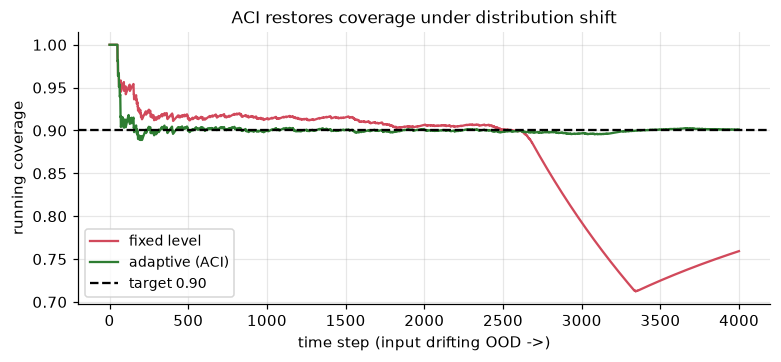

long-run coverage   fixed: 0.75    ACI: 0.90    (target 0.90)


In [4]:
T = 4000
xs = np.linspace(-2, 5, T)                       # input drifts out of the training domain
ys = f(xs) + rng.normal(0, noise, T)
scores = np.abs(ys - model(xs))                  # nonconformity scores along the drift

def online(adaptive, gamma=0.02, warm=50):
    at = alpha; covered = np.zeros(T, bool)
    for t in range(T):
        if t < warm:
            covered[t] = True;
            if adaptive: at = at + gamma*(alpha - 0)
            continue
        lvl = 1 - min(max(at, 0.0), 1.0) if adaptive else 1 - alpha
        qt = np.quantile(scores[:t], lvl)        # quantile of past scores at the (adapted) level
        c = scores[t] <= qt; covered[t] = c
        if adaptive: at = at + gamma*(alpha - (0.0 if c else 1.0))
    return covered

run_cov = lambda c: np.cumsum(c)/np.arange(1, len(c)+1)
cov_fix, cov_aci = online(False), online(True)
plt.figure(figsize=(7.2, 3.4))
plt.plot(run_cov(cov_fix), color="#d1495b", label="fixed level")
plt.plot(run_cov(cov_aci), color="#2e7d32", label="adaptive (ACI)")
plt.axhline(1-alpha, ls="--", color="k", label="target %.2f" % (1-alpha))
plt.xlabel("time step (input drifting OOD ->)"); plt.ylabel("running coverage")
plt.title("ACI restores coverage under distribution shift"); plt.legend(loc="lower left"); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()
print("long-run coverage   fixed: %.2f    ACI: %.2f    (target %.2f)"
      % (cov_fix[100:].mean(), cov_aci[100:].mean(), 1-alpha))

## Part C - A research roadmap

Where a serious version of this system would go, with the mathematics named and the
literature to start from.

**1. Chance-constrained / stochastic MPC instead of LQR.** Replace the regulator with
a predictive controller that keeps the lane with high probability,
$\mathbb P(|e_y|\le e_{\max})\ge 1-\varepsilon$ over a horizon, propagating the
perception covariance $\Sigma^{AI}$ into constraint *tightening*. This turns the
integrity signal into a rigorous safety margin rather than a speed heuristic [9].

**2. Learned driver state.** Replace the scalar workload $W$ with an estimate from
gaze, reaction time, or steering entropy, so authority $\lambda=\Phi(I,W)$ reflects the
*real* driver - the workload-adaptive-shared-control direction [notebook 07, ref 9].

**3. Perception with built-in, calibrated uncertainty.** Swap the synthetic sensor and
the ensemble for evidential or prior-network heads that output a distribution directly
[10,11], trained on real images (and a photoreal simulator such as CARLA), with the
NIS/ODD monitor wrapped around the real network.

**4. Runtime assurance and formal guarantees.** Frame the contracted-envelope mode as a
verified **safety controller** and switch to it under low integrity - a Simplex /
runtime-assurance architecture [12] - and certify the safe set with **control barrier
functions** or reachability [13], moving from a heuristic score toward an assured
envelope.

**5. Integrity with a bound, not a score.** Borrow the aviation notion of a
**protection level**: instead of $I\in[0,1]$, compute a statistical bound on the state
error that holds with a target integrity risk, using the conformal or GLR machinery
above. This is the path from "monitor" to "safety case".

**6. Higher-fidelity plant and closed-loop learning.** A dynamic bicycle with tyre
slip and actuator lag (notebook 01), longitudinal control, and end-to-end evaluation
where the monitored perception feeds the controller in a realistic simulator.

## You have finished the course

Across nine notebooks you built, from first principles, a small but complete
trustworthy-autonomy stack and the theory under each piece: a vehicle model and an
optimal controller; a camera model and a perception front-end with calibrated,
decomposed uncertainty; a Kalman monitor whose innovations are white and whose NIS is
chi-squared; an operational-design-domain check; a fused integrity score evaluated by
ROC and detection delay; and an integrity-aware shared controller whose authority
follows trust. The capstone showed, with a controlled and statistically-tested
experiment, that using AI perception *through* a monitoring layer is safer than
trusting it or switching away from it - and this notebook showed how to make each
piece rigorous. That is the core of trustworthy interactive autonomous driving.

### Exercises

1. Derive the CUSUM increment $z_k-k_{ref}$ from the Gaussian-mean log-likelihood ratio
   and identify $k_{ref}$ in terms of $\mu_0,\mu_1,\sigma$.
2. Add the CUSUM to `courselib`'s integrity monitor (feed it the NIS) and re-run the
   capstone `ood_curve` ablation with NIS-only. Does the cumulative test now hold
   integrity down where the single-sample score could not?
3. Implement a normalized (self-starting) CUSUM that estimates $\mu_0,\sigma$ online.
4. For conformal, use a *normalized* nonconformity score $|y-\hat f(x)|/\hat\sigma(x)$
   with the ensemble's $\hat\sigma$ and compare interval sharpness to the constant-width version.

## References

1. E. S. Page. *Continuous Inspection Schemes.* Biometrika, 41(1/2):100-115, 1954. doi:10.2307/3001968
2. A. Wald. *Sequential Analysis.* Wiley, 1947. (Sequential probability ratio test.)
3. G. Lorden. *Procedures for Reacting to a Change in Distribution.* Annals of Mathematical Statistics, 42(6):1897-1908, 1971. doi:10.1214/aoms/1177693055
4. M. Basseville, I. V. Nikiforov. *Detection of Abrupt Changes: Theory and Application.* Prentice Hall, 1993.
5. V. Vovk, A. Gammerman, G. Shafer. *Algorithmic Learning in a Random World.* Springer, 2005.
6. J. Lei, M. G'Sell, A. Rinaldo, R. J. Tibshirani, L. Wasserman. *Distribution-Free Predictive Inference for Regression.* Journal of the American Statistical Association, 113(523):1094-1111, 2018. doi:10.1080/01621459.2017.1307116
7. A. N. Angelopoulos, S. Bates. *A Gentle Introduction to Conformal Prediction and Distribution-Free Uncertainty Quantification.* Foundations and Trends in ML, 2023. arXiv:2107.07511
8. I. Gibbs, E. Candes. *Adaptive Conformal Inference Under Distribution Shift.* NeurIPS, 2021. arXiv:2106.00170
9. A. Mesbah. *Stochastic Model Predictive Control: An Overview and Perspectives for Future Research.* IEEE Control Systems Magazine, 36(6):30-44, 2016. doi:10.1109/MCS.2016.2602087
10. A. Amini, W. Schwarting, A. Soleimany, D. Rus. *Deep Evidential Regression.* NeurIPS, 2020. arXiv:1910.02600
11. A. Malinin, M. Gales. *Predictive Uncertainty Estimation via Prior Networks.* NeurIPS, 2018. arXiv:1802.10501
12. L. Sha. *Using Simplicity to Control Complexity.* IEEE Software, 18(4):20-28, 2001. doi:10.1109/MS.2001.936213 (Simplex / runtime assurance.)
13. A. D. Ames, S. Coogan, M. Egerstedt, G. Notomista, K. Sreenath, P. Tabuada. *Control Barrier Functions: Theory and Applications.* European Control Conference, 2019. doi:10.23919/ECC.2019.8796030